# Assignment: Medical Insurance Cost Prediction

## Objective

Build a multiple linear regression model to predict medical insurance charges.

You will use a real-world-style insurance dataset with demographic and health-related features.

Target column:

$$
charges
$$

By the end of this assignment, you should be able to:

- perform EDA on a regression dataset,
- handle categorical variables,
- engineer useful features,
- build a preprocessing + regression pipeline,
- evaluate with MAE, RMSE, R2, and adjusted R2,
- interpret coefficients carefully,
- diagnose residual patterns,
- explain whether linear regression is suitable for the problem.

## Dataset columns

- `age`: age of primary beneficiary
- `sex`: gender
- `bmi`: body mass index
- `children`: number of children/dependents covered
- `smoker`: whether the person smokes
- `region`: residential area in the US
- `charges`: individual medical insurance charges

This is a regression problem because `charges` is a continuous numeric target.

## Submission requirements

Submit:

1. Completed `.ipynb` notebook.
2. 5-8 bullet-point summary of your findings.
3. Key plots:
   - target distribution,
   - actual vs predicted,
   - residuals vs predicted,
   - coefficient importance.

Write short explanations wherever asked. Do not only submit code outputs.

In [3]:
import warnings
from pathlib import Path
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 50)

## 1. Load the dataset

The code below will:

- use the local dataset if available,
- otherwise download it from the internet.

In [4]:
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

DATA_PATH = DATA_DIR / "insurance.csv"
DATA_URL = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"

if not DATA_PATH.exists():
    print("Dataset not found locally. Downloading...")
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)
    print(f"Downloaded dataset to: {DATA_PATH}")
else:
    print(f"Using local dataset: {DATA_PATH}")

insurance = pd.read_csv(DATA_PATH)
insurance.head()

Using local dataset: data\insurance.csv


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 2. Basic inspection

Complete the following:

1. Print dataset shape.
2. Display first 5 rows.
3. Check column data types.
4. Check missing values.
5. Show summary statistics.

In [5]:
# TODO: Print the shape of the dataset
insurance.shape

(1338, 7)

In [6]:
# TODO: Display first 5 rows
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [7]:
# TODO: Check data types and missing values
insurance.info()
# no null entries in any of the columns. All columns have non-null values.

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [8]:
# TODO: Show summary statistics for numerical columns
insurance.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


### Written answer

Answer briefly:

1. How many rows and columns are present? There are 1338 rows and 7 columns
2. Are there any missing values? There are no missing values in any of the columns.
3. Which columns are numerical and which are categorical? Age, BMI and children are numerical columns. Sex, Smoker and Region are categorical

## 3. Exploratory Data Analysis

Create visualizations to understand the target and feature relationships.

<Axes: xlabel='charges', ylabel='Count'>

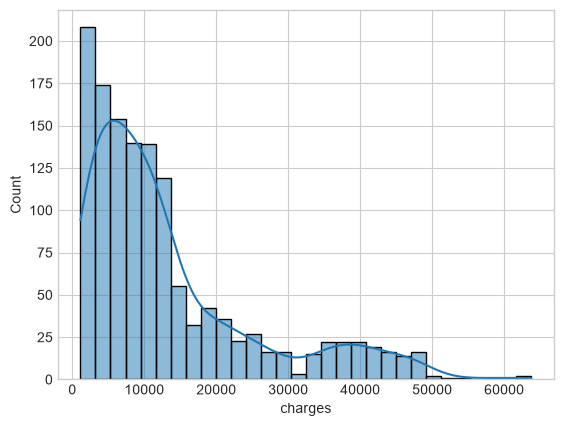

In [9]:
# TODO: Plot distribution of charges
import seaborn as sns
sns.histplot(data=insurance, x="charges", kde=True)

<Axes: xlabel='age', ylabel='charges'>

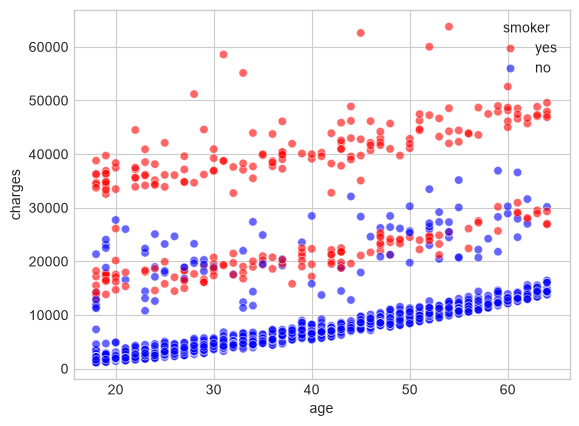

In [10]:
# TODO: Plot age vs charges
sns.scatterplot(data=insurance, x="age", y="charges", hue="smoker", palette={"yes": "red", "no": "blue"}, alpha=0.6)

<Axes: xlabel='bmi', ylabel='charges'>

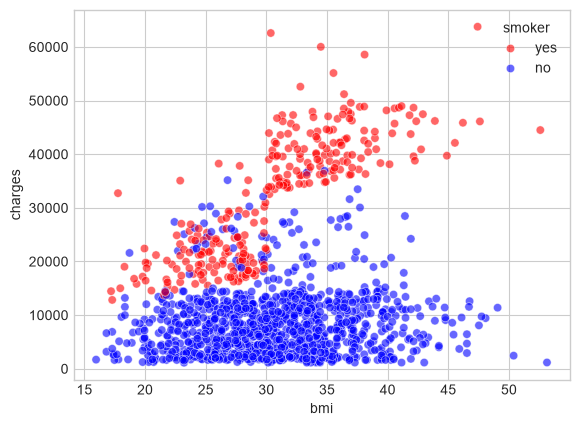

In [11]:
# TODO: Plot BMI vs charges
sns.scatterplot(data=insurance, x="bmi", y="charges", hue="smoker", palette={"yes": "red", "no": "blue"}, alpha=0.6)

<Axes: xlabel='smoker', ylabel='charges'>

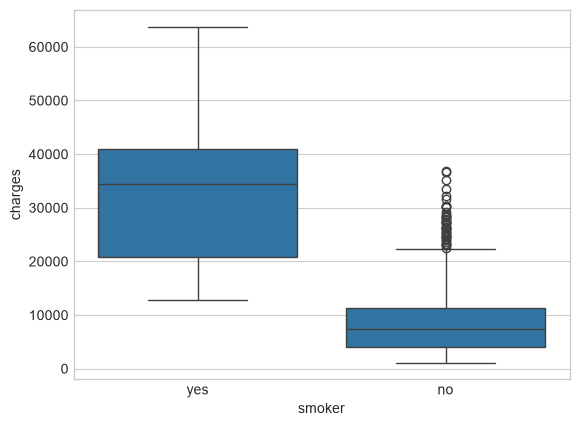

In [12]:
# TODO: Compare charges for smokers and non-smokers
# Hint: boxplot works well here
sns.boxplot(data=insurance, x="smoker", y="charges")

<Axes: xlabel='region', ylabel='charges'>

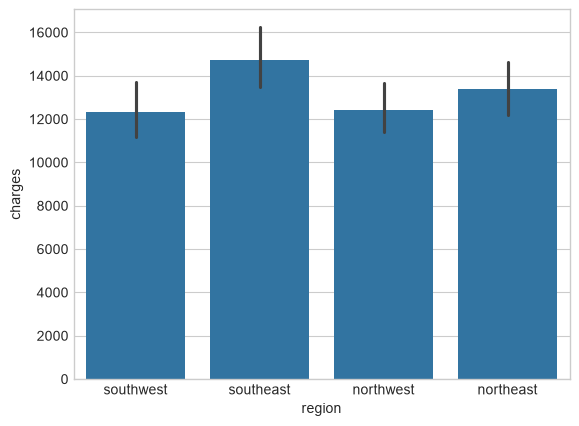

In [13]:
# TODO: Compare average charges by region
sns.barplot(data=insurance, x="region", y="charges")

<Axes: >

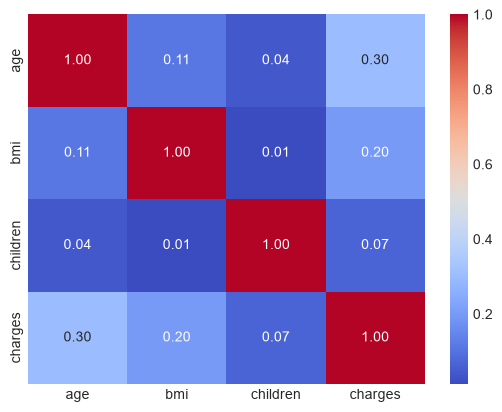

In [14]:
# TODO: Create a correlation heatmap for numerical columns
numerical_cols = insurance.select_dtypes(include=[np.number]).columns
correlation_matrix = insurance[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")

### EDA questions

Answer briefly:

1. Is `charges` normally distributed or skewed? Charges is skewed
2. Does smoking seem to affect charges? Yes, clearly the median of charges is much higher for smokers as compared to non smokers
3. Does BMI show a clear relationship with charges? No clear relationship with charges, especially in case of non-smokers
4. Which numerical feature has the strongest correlation with `charges`? of all the numeric features, age has the maximum correlation

## 4. Feature engineering

Create at least three new features.

Required:

1. `is_obese`

$$
is\_obese =
\begin{cases}
1, & BMI \ge 30 \\
0, & BMI < 30
\end{cases}
$$

2. `age_group`: group ages into buckets.

3. `smoker_bmi`: interaction between smoking and BMI.

Why interaction?

The impact of BMI may be different for smokers and non-smokers.

In [15]:
insurance_fe = insurance.copy()

# TODO: Create is_obese
insurance_fe["is_obese"] = (insurance_fe["bmi"] >= 30).astype(int)

# TODO: Create age_group
# Suggested bins: [0, 25, 35, 45, 55, 65, 100]
# Suggested labels: ["<=25", "26-35", "36-45", "46-55", "56-65", "65+"]
insurance_fe["age_group"] = pd.cut(insurance_fe["age"], bins=[0, 25, 35, 45, 55, 65, 100], labels=["<=25", "26-35", "36-45", "46-55", "56-65", "65+"])

# TODO: Create smoker_bmi
# Hint: convert smoker yes/no to 1/0, then multiply by bmi
insurance_fe["smoker_bmi"] = (insurance_fe["smoker"].map({"yes": 1, "no": 0}) * insurance_fe["bmi"])

insurance_fe.head()

,age,sex,bmi,children,smoker,region,charges,is_obese,age_group,smoker_bmi
0,19,female,27.900,0,yes,southwest,16884.92400,0,<=25,27.9
1,18,male,33.770,1,no,southeast,1725.55230,1,<=25,0.0
2,28,male,33.000,3,no,southeast,4449.46200,1,26-35,0.0
3,33,male,22.705,0,no,northwest,21984.47061,0,26-35,0.0
4,32,male,28.880,0,no,northwest,3866.85520,0,26-35,0.0


<Axes: xlabel='is_obese', ylabel='charges'>

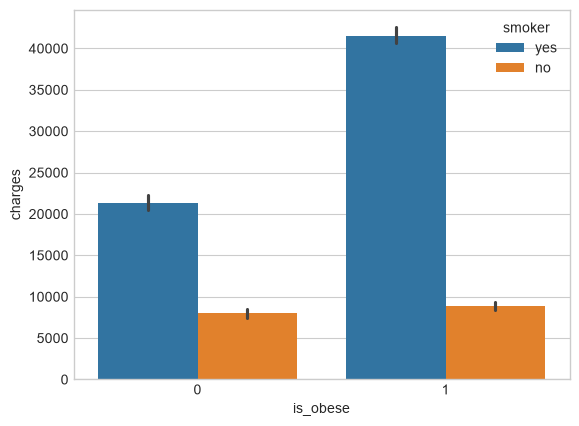

In [16]:
# TODO: Visualize charges by is_obese and smoker
sns.barplot(data=insurance_fe, x="is_obese", y="charges", hue="smoker")

### Feature engineering questions

Answer briefly:

1. Why might `is_obese` be useful? obesity might have a effect on charges hence, ctegorising obesity levels into 2 might give a clearer idea about the data
2. Why might `smoker_bmi` be useful? bmi clubbed with smoking information is more useful as can be seen in the above plot, generally te trend shows that smokers have a higher charge
3. Which engineered feature do you expect to help the model most? smoker_bmi should be helpful.

## 5. Train-test split

Use:

- 80% training data
- 20% test data
- `random_state=42`

Target:

$$
y = charges
$$

In [17]:
target = "charges"

# TODO: Create X and y
X = insurance_fe.drop(columns=[target])
y = insurance_fe[target]

# TODO: Split into X_train, X_test, y_train, y_test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.dtypes  

age              int64
sex                str
bmi            float64
children         int64
smoker             str
region             str
is_obese         int64
age_group     category
smoker_bmi     float64
dtype: object

## 6. Build preprocessing and model pipeline

Your pipeline should:

1. impute numerical missing values if any,
2. scale numerical features,
3. one-hot encode categorical features,
4. train Linear Regression.

In [18]:
# TODO: Identify numerical and categorical columns

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=[object, "category"]).columns.tolist()

numeric_features, categorical_features

(['age', 'bmi', 'children', 'is_obese', 'smoker_bmi'],
 ['sex', 'smoker', 'region', 'age_group'])

In [19]:
# TODO: Build preprocessing pipelines

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [20]:
# TODO: Build and train Linear Regression pipeline

linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

linear_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['age','sex','bmi',...,'is_obese','age_group','smoker_bmi']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concate

## 7. Evaluation metrics

Evaluate on test data using:

$$
MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|
$$

$$
RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}
$$

$$
R^2 = 1 - \frac{SS_{res}}{SS_{tot}}
$$

Also calculate adjusted R2:

$$
Adjusted\ R^2 = 1 - \frac{(1-R^2)(n-1)}{n-p-1}
$$

In [21]:
def regression_report(y_true, y_pred, n_features=None):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    report = {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }
    
    if n_features is not None:
        n = len(y_true)
        p = n_features
        adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
        report["Adjusted R2"] = adjusted_r2
    
    return pd.Series(report)

In [22]:
# TODO: Generate predictions on train and test data
y_train_pred = linear_model.predict(X_train)
y_test_pred = linear_model.predict(X_test)
# TODO: Calculate number of transformed features

# TODO: Print train and test regression reports
regression_report(y_train, y_train_pred)

MAE     2.853722e+03
MSE     2.244349e+07
RMSE    4.737456e+03
R2      8.445027e-01
dtype: float64

In [23]:
regression_report(y_test, y_test_pred)

MAE     2.760987e+03
MSE     2.083316e+07
RMSE    4.564336e+03
R2      8.658079e-01
dtype: float64

### Evaluation questions

Answer briefly:

1. What is the model's RMSE?
2. What is the model's R2?
3. Is train performance much better than test performance?
4. Does the model appear to overfit?

## 8. Visualize predictions and residuals

Create:

1. Actual vs predicted plot.
2. Residuals vs predicted plot.
3. Residual distribution.

Residual:

$$
e_i = y_i - \hat{y}_i
$$

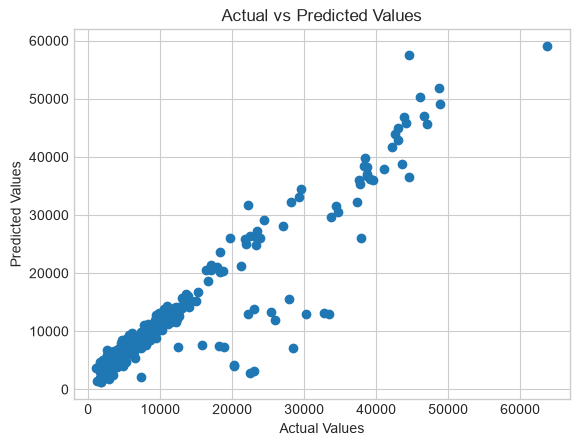

In [24]:
# TODO: Actual vs predicted plot
plt.scatter(y_test, y_test_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()

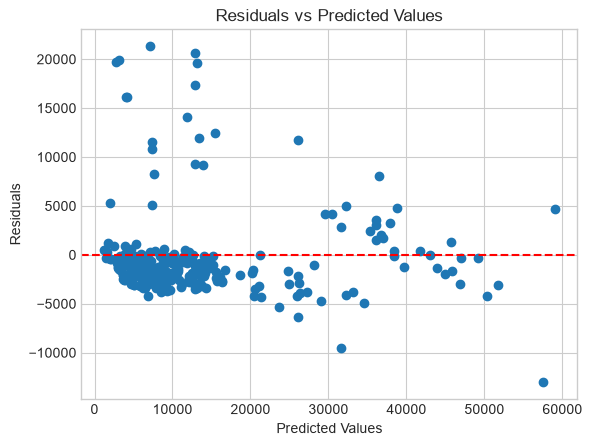

In [25]:
# TODO: Residuals vs predicted plot
residuals = y_test - y_test_pred
plt.scatter(y_test_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.show()  

<Axes: xlabel='charges', ylabel='Count'>

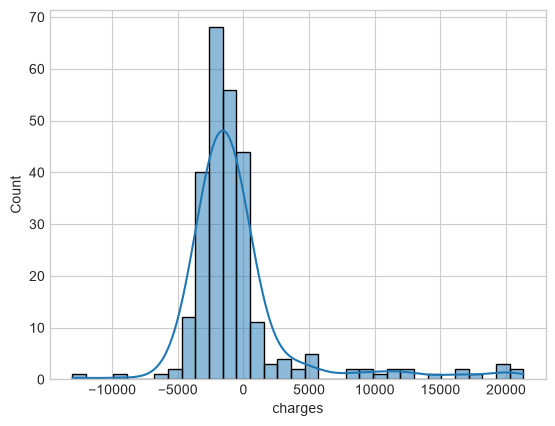

In [26]:
# TODO: Residual distribution plot
sns.histplot(residuals, kde=True)

### Residual questions

Answer briefly:

1. Are residuals centered around zero? Yes, but the distribution looks uneven
2. Do residuals show a pattern? Yes, we see a funnel kind of shape
3. Does the model make larger errors for high-charge customers? Yes, it endsup overpredicting or underpredicting

## 9. Coefficient interpretation

Extract model coefficients and identify:

- top positive coefficients,
- top negative coefficients.

Be careful:

> A coefficient shows association, not guaranteed causation.

In [27]:
# TODO: Extract transformed feature names and coefficients
feature_names = linear_model[:-1].get_feature_names_out()
feature_names

array(['num__age', 'num__bmi', 'num__children', 'num__is_obese',
       'num__smoker_bmi', 'cat__sex_female', 'cat__sex_male',
       'cat__smoker_no', 'cat__smoker_yes', 'cat__region_northeast',
       'cat__region_northwest', 'cat__region_southeast',
       'cat__region_southwest', 'cat__age_group_26-35',
       'cat__age_group_36-45', 'cat__age_group_46-55',
       'cat__age_group_56-65', 'cat__age_group_<=25'], dtype=object)

In [28]:
coefficients = linear_model.named_steps["regressor"].coef_
df_coef = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
print(df_coef)

                  Feature   Coefficient
0                num__age   6015.073093
1                num__bmi  -1261.172630
2           num__children    688.195035
3           num__is_obese   1625.317190
4         num__smoker_bmi  18661.995075
5         cat__sex_female    273.104900
6           cat__sex_male   -273.104900
7          cat__smoker_no  10680.643287
8         cat__smoker_yes -10680.643287
9   cat__region_northeast    693.702837
10  cat__region_northwest    -30.672449
11  cat__region_southeast   -114.821153
12  cat__region_southwest   -548.209235
13   cat__age_group_26-35   1377.829360
14   cat__age_group_36-45   -903.658784
15   cat__age_group_46-55  -1682.625982
16   cat__age_group_56-65  -2720.541659
17    cat__age_group_<=25   3928.997066


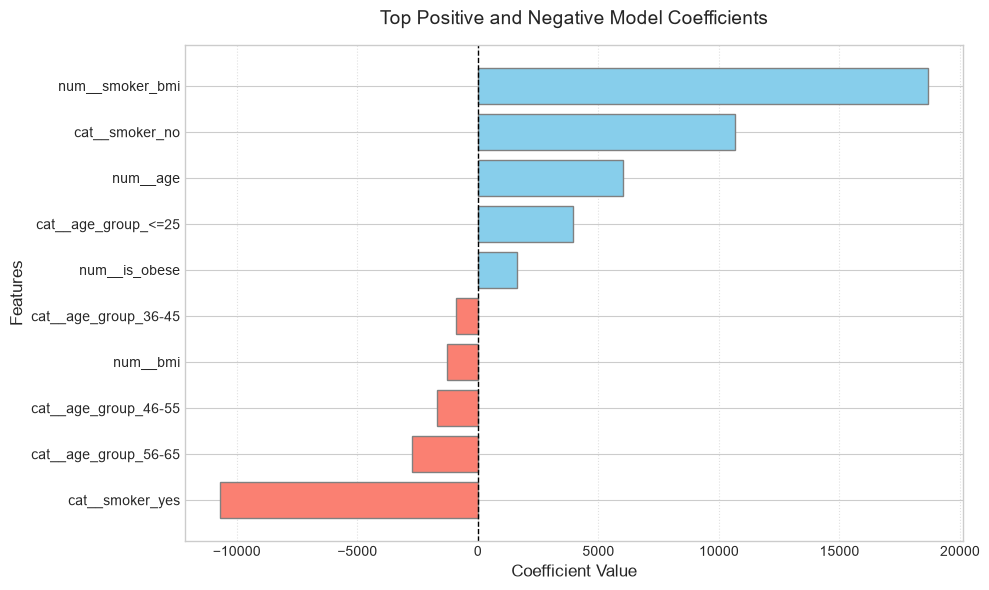

In [29]:
# TODO: Plot top positive and negative coefficients

data = {
    'Feature': feature_names,
    'Coefficient': coefficients,
}
df = pd.DataFrame(data)

df_sorted = df.sort_values(by='Coefficient', ascending=False)
top_positive = df_sorted.head(5)
top_negative = df_sorted.tail(5)

plot_df = (
    pd.concat([top_positive, top_negative])
    .drop_duplicates()
    .sort_values(by='Coefficient', ascending=True)
)

plt.figure(figsize=(10, 6))


colors = np.where(plot_df['Coefficient'] > 0, 'skyblue', 'salmon')

plt.barh(plot_df['Feature'], plot_df['Coefficient'], color=colors, edgecolor='grey')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)

# Add titles and clean up labels
plt.title('Top Positive and Negative Model Coefficients', fontsize=14, pad=15)
plt.xlabel('Coefficient Value', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


### Coefficient questions

Answer briefly:

1. Which features increase predicted charges the most? the interaction of smoking and bmi value i.e smoker_bmi significantly increase the medical charges
2. Which features decrease predicted charges? Smoker_yes, but that looks unusual, it should be smoker no - probably this and smoker no both shold be dropped as smoker_bmi takes care of this 
3. How strong is the impact of smoking? smoking singlehandedly impact the charges enormously
4. Are the coefficient signs reasonable? The smoker_yes vs smoker_no signs look inverted.

## 10. Multicollinearity check

Check correlation among numerical features.

High feature-feature correlation can make coefficient interpretation unstable.

<Axes: >

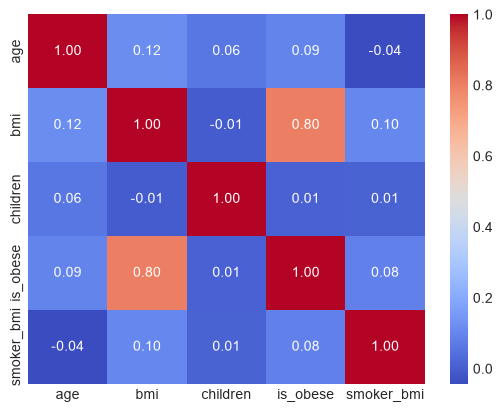

In [40]:
# TODO: Correlation heatmap among numerical features
numerical_features = X_train.select_dtypes(include=[np.number]).columns
correlation_matrix = X_train[numerical_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")

In [31]:
# TODO: Show highly correlated feature pairs

### Multicollinearity questions

Answer briefly:

1. Which features are highly correlated?
2. Could this affect coefficient interpretation?
3. Would you remove any features? Why?

## 11. Compare with Ridge Regression

Ridge adds a penalty for large coefficients:

$$
\text{Ridge: } \min(MSE + \lambda\sum_j \beta_j^2)
$$

Train a Ridge model and compare it with Linear Regression.

In [32]:
# TODO: Build and train Ridge regression pipeline

ridge_model = None

In [33]:
# TODO: Compare Linear Regression and Ridge using MAE, RMSE, R2, adjusted R2

### Ridge questions

Answer briefly:

1. Did Ridge improve test performance?
2. Did Ridge reduce coefficient magnitudes?
3. Why might regularization help?

## 12. Stretch goals

Try any two:

1. Compare with Lasso Regression.
2. Apply log transform to `charges` and compare performance.
3. Train separate models for smokers and non-smokers.
4. Add polynomial features for `age` or `bmi`.
5. Remove highly correlated features and retrain.

In [34]:
# Optional stretch work here

## Final written summary

Write 5-8 bullet points:

1. What were the most important findings from EDA?
2. Which model performed better?
3. Which features were most influential?
4. Where did the model make larger mistakes?
5. Is linear regression sufficient for this dataset?
6. What would you try next to improve the model?